# Load dataset and inspect its basic structure

In [ ]:
# Load dataset and inspect its basic structure

import pandas as pd
import numpy as np

df = pd.read_csv("../data/employee_attrition.csv")

print("Shape:", df.shape)

df.head()
df.info()

print(df['Attrition'].value_counts())
print(df.isnull().sum().sum(), "total missing values")


Shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 no

In [2]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [3]:
# Remove irrelevant and non-informative columns
drop_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Remaining columns:", df.shape[1])

Remaining columns: 31


In [4]:
# Encode the target variable and check the class distribution
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

df['Attrition'].value_counts(normalize=True)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

## 2. Exploratory Data Analysis

In [5]:
# Import visualization libraries and create the output directory
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../outputs/figures", exist_ok=True)

sns.set_style("whitegrid")

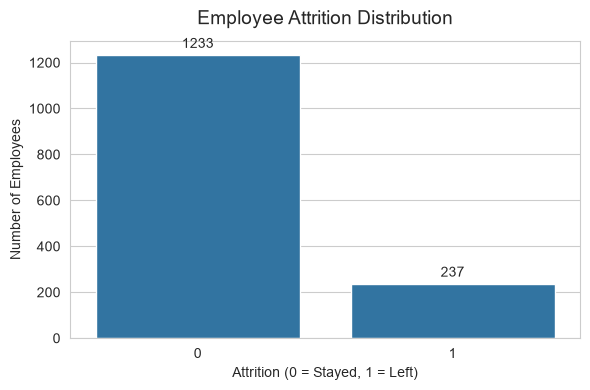

In [7]:
# Plot overall attrition distribution

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x='Attrition',
    order=[0, 1]
)

plt.title("Employee Attrition Distribution", fontsize=14, pad=12)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig("../outputs/figures/01_attrition_overall.png", dpi=300, bbox_inches='tight')
plt.show()

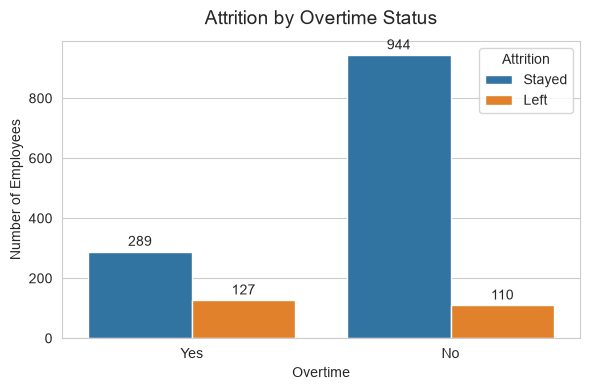

In [8]:
# Compare attrition across overtime status

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.title("Attrition by Overtime Status", fontsize=14, pad=12)
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["Stayed", "Left"])

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/02_attrition_overtime.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

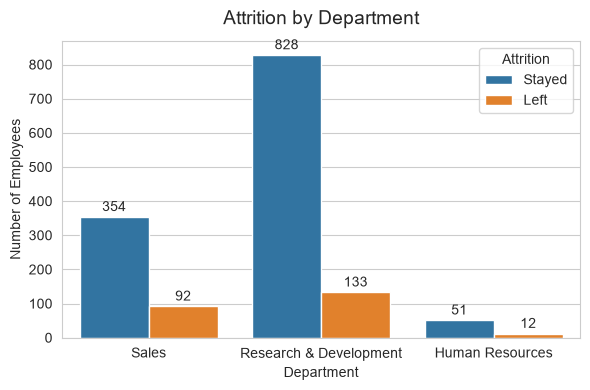

In [9]:
# Compare attrition across departments

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x='Department',
    hue='Attrition'
)

plt.title("Attrition by Department", fontsize=14, pad=12)
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(title="Attrition", labels=["Stayed", "Left"])

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/03_attrition_department.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

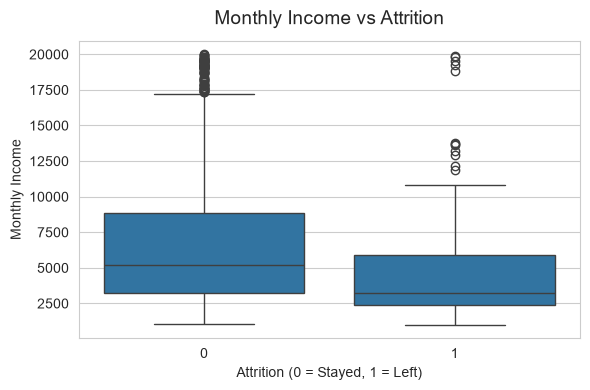

In [10]:
# Compare monthly income distribution by attrition

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Monthly Income vs Attrition", fontsize=14, pad=12)
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.savefig(
    "../outputs/figures/04_income_vs_attrition.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

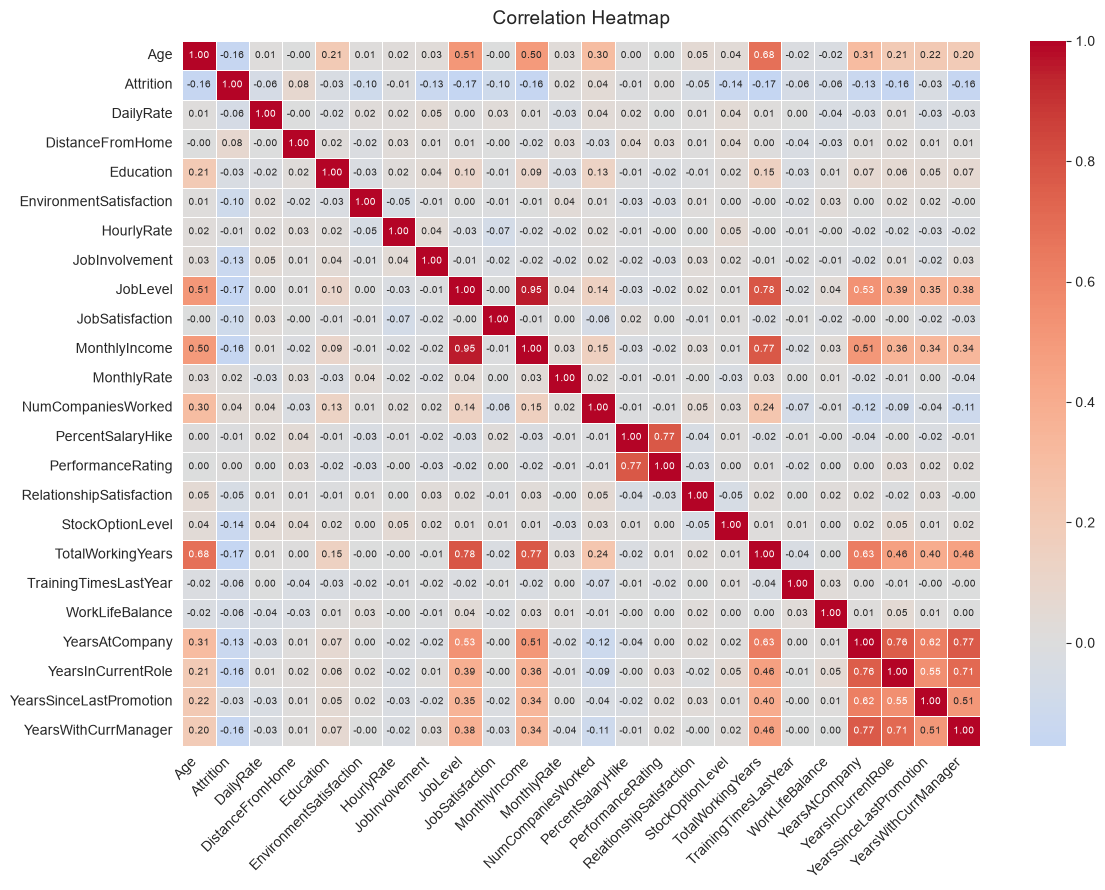

In [11]:
# Visualize correlations among numerical features

plt.figure(figsize=(12, 9))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)

plt.title("Correlation Heatmap", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../outputs/figures/05_correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Key EDA Insights

- Employees who work overtime show a noticeably higher attrition rate than those who do not.
- Sales has a higher proportion of employees leaving compared with the other departments.
- Employees who left generally have lower monthly income distributions than those who stayed.
- Most numerical features show relatively weak correlations with attrition, suggesting that attrition is influenced by multiple factors.

## 3. Data Preprocessing

Convert categorical features into numerical form so they can be used by the machine learning models.

In [12]:
# Encode categorical features using one-hot encoding

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Shape after encoding:", df_encoded.shape)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 45)


C:\Users\Dakshita\AppData\Local\Temp\ipykernel_23908\426999804.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [13]:
# Prepare features and target, then split into training and testing sets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1176, 44)
Testing set: (294, 44)


## 4. Model Building

### 4.1 Logistic Regression

Standardize the features and train a Logistic Regression model to predict employee attrition.

In [15]:
# Scale features and train the Logistic Regression model

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

In [16]:
# Train the Random Forest model and generate predictions

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

## 5. Model Evaluation

Evaluate both models using accuracy, precision, recall, F1-score, ROC-AUC, and the confusion matrix.

In [17]:
def evaluate(name, y_true, preds, probs):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, preds), 3))
    print("Precision:", round(precision_score(y_true, preds), 3))
    print("Recall:   ", round(recall_score(y_true, preds), 3))
    print("F1 Score: ", round(f1_score(y_true, preds), 3))
    print("ROC-AUC:  ", round(roc_auc_score(y_true, probs), 3))
    print("Confusion Matrix:\n", confusion_matrix(y_true, preds))
    print()

evaluate("Logistic Regression", y_test, log_preds, log_probs)
evaluate("Random Forest", y_test, rf_preds, rf_probs)

--- Logistic Regression ---
Accuracy:  0.752
Precision: 0.345
Recall:    0.617
F1 Score:  0.443
ROC-AUC:   0.798
Confusion Matrix:
 [[192  55]
 [ 18  29]]

--- Random Forest ---
Accuracy:  0.823
Precision: 0.419
Recall:    0.277
F1 Score:  0.333
ROC-AUC:   0.778
Confusion Matrix:
 [[229  18]
 [ 34  13]]



## 6. Feature Importance

Identify the features that contribute most to the Random Forest's predictions.

MonthlyIncome           0.075518
Age                     0.061215
TotalWorkingYears       0.051915
DailyRate               0.050251
YearsAtCompany          0.049284
OverTime_Yes            0.045947
MonthlyRate             0.045809
HourlyRate              0.043147
DistanceFromHome        0.042797
YearsWithCurrManager    0.042588
dtype: float64


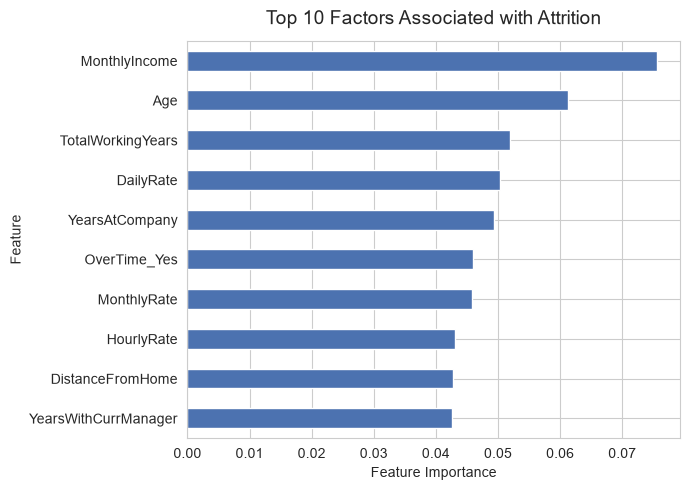

In [18]:
# Calculate and visualize the top 10 feature importances

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

top10 = importances.sort_values(ascending=False).head(10)

print(top10)

plt.figure(figsize=(7, 5))

top10.sort_values().plot(
    kind='barh',
    color='#4C72B0'
)

plt.title("Top 10 Factors Associated with Attrition", fontsize=14, pad=12)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(
    "../outputs/figures/06_feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 7. Employee Risk Classification

Convert the predicted attrition probability into three risk levels: Low, Medium, and High.

In [19]:
# Convert predicted attrition probability into a risk level

def risk_level(prob):
    if prob < 0.33:
        return "Low"
    elif prob < 0.66:
        return "Medium"
    else:
        return "High"


# Quick sanity check on the test set
sample = pd.DataFrame({
    "probability": rf_probs[:10]
})

sample["risk"] = sample["probability"].apply(risk_level)

print(sample)

   probability    risk
0        0.775    High
1        0.140     Low
2        0.200     Low
3        0.045     Low
4        0.400  Medium
5        0.170     Low
6        0.125     Low
7        0.200     Low
8        0.035     Low
9        0.560  Medium


## 8. Save Model Artifacts

Save the trained Logistic Regression model, scaler, and feature column order for use in the Streamlit application.

In [22]:
# Save the trained model, scaler, and feature column order

import joblib
import os

os.makedirs("../outputs", exist_ok=True)

joblib.dump(
    log_model,
    "../outputs/attrition_model.pkl"
)

joblib.dump(
    scaler,
    "../outputs/scaler.pkl"
)

joblib.dump(
    list(X.columns),
    "../outputs/model_columns.pkl"
)

print("Logistic Regression model, scaler, and columns saved.")

Logistic Regression model, scaler, and columns saved.
